In [11]:
import mysql.connector
from dotenv import load_dotenv
import os

# connect notebook to sql database

load_dotenv()

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password=os.getenv('MYSQL_PASSWORD'),
    database='claims_practice'
)

print("Connection successful" if conn.is_connected() else "Connection failed")

Connection successful


In [12]:
import pandas as pd

# Verify df read properly with head()

with open('../queries/06_readmission_by_drg.sql', 'r') as f:
    query = f.read()
df = pd.read_sql(query, conn)
print(df.head())

/var/folders/4_/dbg0kzhn7354xv35_by_4slr0000gn/T/ipykernel_52098/3415955804.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


  CLM_DRG_CD  readmission_rate  total_admissions
0        813              0.23                57
1        815              0.19                59
2        665              0.19                77
3        513              0.19                80
4        037              0.18                77


## Benchmark Reference
All-cause 30-day hospital readmission rate benchmark: 14.67%

Source: Definitive Healthcare. (2025, March). *Average hospital readmission rate by state*. 
Data originally sourced from CMS. 
https://www.definitivehc.com/resources/healthcare-insights/average-hospital-readmission-state

Note: This is an all-cause benchmark, not DRG-specific. A more precise comparison 
would require condition-specific rates from CMS HRRP published data.

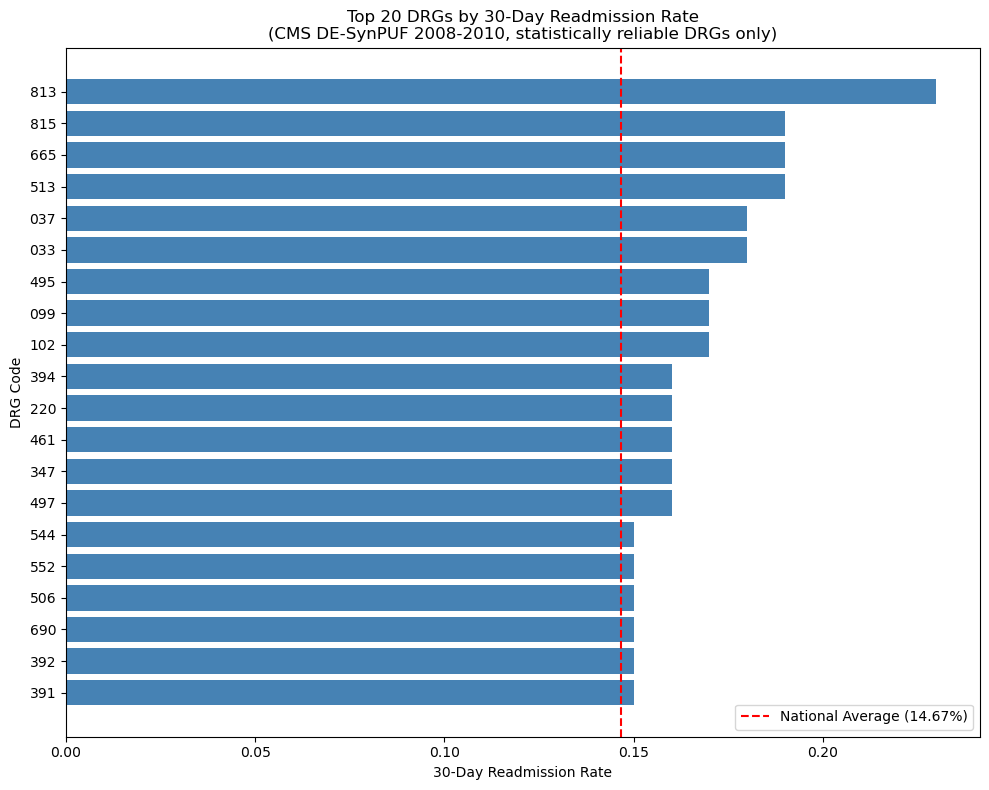

In [14]:
# Visualize the top 20 DRG readmission rates and compare against all cause national average

import matplotlib.pyplot as plt

top20 = df.head(20).sort_values('readmission_rate')

plt.figure(figsize=(10, 8))
plt.barh(top20['CLM_DRG_CD'].astype(str), top20['readmission_rate'], color='steelblue')
plt.axvline(x=0.1467, color='red', linewidth=1.5, linestyle='--', label='National Average (14.67%)')
plt.legend()
plt.xlabel('30-Day Readmission Rate')
plt.ylabel('DRG Code')
plt.title('Top 20 DRGs by 30-Day Readmission Rate\n(CMS DE-SynPUF 2008-2010, statistically reliable DRGs only)')
plt.tight_layout()
plt.savefig('../images/top20_drg_readmission_rate.png', dpi=150, bbox_inches='tight')
plt.show()
